## Lecture Demo + Solutions

## MNIST - code example

We will be using Tensorflow/Keras, a very popular library for building neural networks. You can find the Keras documentation at https://keras.io/

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r".*Protobuf gencode version.*one major version older than the runtime version.*",
    category=UserWarning,
    module=r"google\.protobuf\.runtime_version",
)

import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import RMSprop, SGD
from cycler import cycler

import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn.metrics import roc_curve, auc

In [3]:
# load the data and split into train/test
mnist = keras.datasets.mnist
num_classes = 10
print('Loading...')
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('...finished')

Loading...
...finished


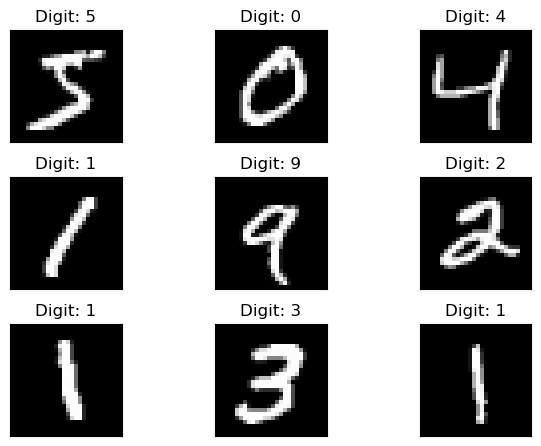

In [4]:
# show a few digits...
fig = plt.figure()
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.tight_layout()
  plt.imshow(x_train[i], cmap='gray', interpolation='none')
  plt.title("Digit: {}".format(y_train[i]))
  plt.xticks([])
  plt.yticks([])
fig
plt.show()

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
# munge the data
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

# Reserve 10,000 samples for validation
x_val = x_train[-10000:]
y_val = y_train[-10000:]
x_train = x_train[:-10000]
y_train = y_train[:-10000]

print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

50000 train samples
10000 test samples


In [7]:
def myeval(model, history):
    # evalute the model quality
    epochs = len(history.history['loss'])
    score = model.evaluate(x_test, y_test, verbose=0)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])
    
    # plot the metrics
    # Create cycler object for the graphs. Use any styling you please
    monochrome = (cycler('color', ['k']) * cycler('linestyle', ['-', '--', ':', '-.']))

    fig = plt.figure()
    ax = plt.axes()
    ax.set_prop_cycle(monochrome)
    plt.plot(history.history['accuracy'],linestyle='--')
    plt.plot(history.history['val_accuracy'],linestyle='-')
    startacc = min([min(history.history['accuracy']), min(history.history['val_accuracy'])])
    plt.ylim([startacc, 1])
    plt.xticks(range(0,epochs))
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    plt.title('model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper left')

    fig = plt.figure()
    ax = plt.axes()
    ax.set_prop_cycle(monochrome)
    plt.plot(history.history['loss'],linestyle='--')
    plt.plot(history.history['val_loss'],linestyle='-')
    plt.xticks(range(0,epochs))
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    plt.title('model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper right')

    plt.show()

## Exercise Solutions

#### Exercise 1: Switch optimizer from SGD to RMSprop and loss function from mean squared error to (categorical) cross-entropy. How does the quality of the network change? Discuss/interpret your results. 

In [8]:
model = Sequential([
    Input(shape=(784,)),
    Dense(16, activation="relu"),
    Dense(16, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

model.summary()

model.compile(
    loss="categorical_crossentropy",
    optimizer=RMSprop(),
    metrics=["accuracy"],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
%%time 

epochs = 48
batch_size = 128
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7630 - loss: 0.8162 - val_accuracy: 0.8997 - val_loss: 0.3555
Epoch 2/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9060 - loss: 0.3281 - val_accuracy: 0.9252 - val_loss: 0.2687
Epoch 3/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9226 - loss: 0.2704 - val_accuracy: 0.9320 - val_loss: 0.2367
Epoch 4/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9306 - loss: 0.2402 - val_accuracy: 0.9345 - val_loss: 0.2284
Epoch 5/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9350 - loss: 0.2223 - val_accuracy: 0.9360 - val_loss: 0.2185
Epoch 6/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9398 - loss: 0.2082 - val_accuracy: 0.9441 - val_loss: 0.1945
Epoch 7/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9424 - loss: 0.1977 - val_accuracy: 0.9416 - val_loss: 0.2020
Epoch 8/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9453 - loss: 0.1886 - val_accuracy: 0.

Test loss: 0.1713997721672058
Test accuracy: 0.9542999863624573


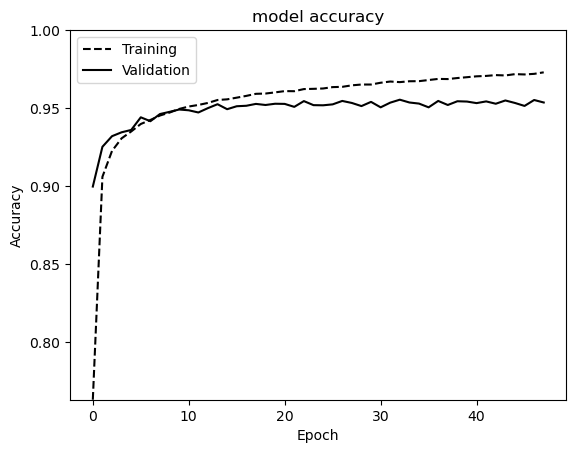

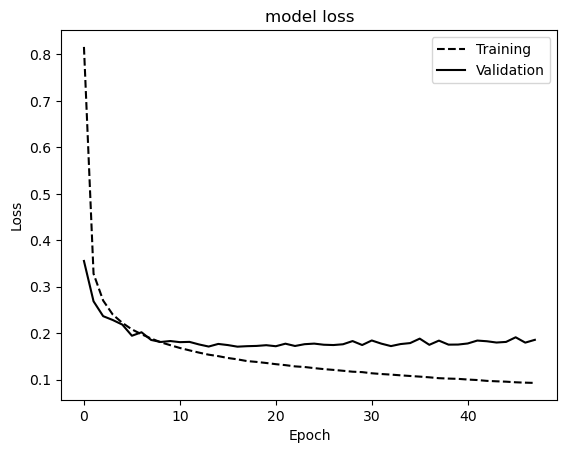

In [10]:
myeval(model, history)

#### Discussion

we finally see good results, the training converges very quickly - after about 20 epochs the performance is stable, around 30 epochs some slight overfitting seems to set in.

#### Exercise 2: Increase the number of neurons in the hidden layers to 256 and the epochs to 64. Again, how does the quality of the network change? Discuss/interpret your results.

In [11]:
model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation="relu"),
    Dense(256, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

model.summary()

model.compile(
    loss="categorical_crossentropy",
    optimizer=RMSprop(),
    metrics=["accuracy"],
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
%%time 

epochs = 64
batch_size = 128
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9140 - loss: 0.2880 - val_accuracy: 0.9620 - val_loss: 0.1346
Epoch 2/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9657 - loss: 0.1119 - val_accuracy: 0.9686 - val_loss: 0.1077
Epoch 3/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9771 - loss: 0.0726 - val_accuracy: 0.9742 - val_loss: 0.0888
Epoch 4/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9843 - loss: 0.0513 - val_accuracy: 0.9752 - val_loss: 0.0883
Epoch 5/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9884 - loss: 0.0370 - val_accuracy: 0.9781 - val_loss: 0.0762
Epoch 6/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9918 - loss: 0.0268 - val_accuracy: 0.9798 - val_loss: 0.0788
Epoch 7/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9931 - loss: 0.0216 - val_accuracy: 0.9794 - val_loss: 0.0812
Epoch 8/64
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9950 - loss: 0.0161 - val_accuracy: 0.

Test loss: 0.10747092217206955
Test accuracy: 0.9836000204086304


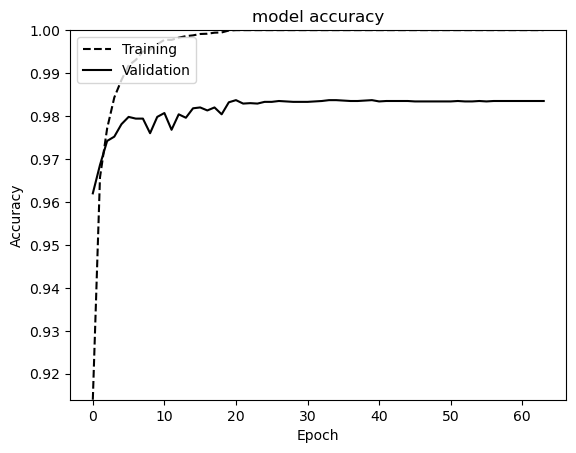

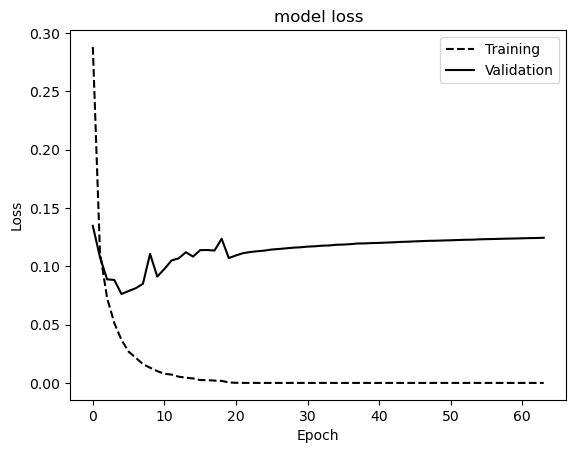

In [13]:
myeval(model, history)

#### Discussion

The accuracy of this network is even better. But, the loss on the validation set increases after around 20 epochs and the accuracy on the test set stops improving, we only see small (stochastical) fluctuations. The network is still getting  better on the training set (the loss is still decreasing), so it seems to be improving, but this is an illusion, what it is learning after epoch 20 does not generalize to the test set. One could say, it just memorizes the training set more and more. After approx. epoch 25-30, there are no significant changes to neither train nor validation accuracy/loos. So what we have here is a case of overfitting/overtraining: training should be stopped after about 20 epochs.

In [14]:
# --- EOF ---